<a href="https://colab.research.google.com/github/nikitask14/neural-networks-pytorch-from-first-principles/blob/main/04_debugging_and_generalisation/15_learning_rate_and_optimizer_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Sitting 15: Learning Rate and Optimiser Experiments

PART A: Learning Rate

In [1]:
import torch
import torch.nn as nn

In [2]:
x_train = torch.tensor([
    [ 2.0,  2.0],
    [ 1.5,  1.0],
    [-2.0, -2.0],
    [-1.5, -1.0],
    [ 2.0, -2.0],
    [ 1.5, -1.0],
    [-2.0,  2.0],
    [-1.5,  1.0]
], dtype = torch.float32)

y_train = torch.tensor([
    [1.0],
    [0.0],   # deliberately noisy label
    [1.0],
    [1.0],
    [0.0],
    [1.0],   # deliberately noisy label
    [0.0],
    [0.0]
], dtype = torch.float32)

x_val = torch.tensor([
    [ 1.8,  1.5],
    [ 1.2,  0.8],
    [-1.8, -1.5],
    [-1.2, -0.8],
    [ 1.8, -1.5],
    [ 1.2, -0.8],
    [-1.8,  1.5],
    [-1.2,  0.8]
],dtype = torch.float32)

y_val = torch.tensor([
    [1.0],
    [1.0],
    [1.0],
    [1.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0]
], dtype = torch.float32)

print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

torch.Size([8, 2])
torch.Size([8, 1])
torch.Size([8, 2])
torch.Size([8, 1])


In [3]:
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(2,16)
    self.layer2 = nn.Linear(16,1)

  def forward(self, x):
    x = self.layer1(x)
    x = torch.relu(x)

    x = self.layer2(x)
    return x
# model(x_train) eventually invokes forward().
# The result of forward() has to be handed back to logits.

This one matters specifically because of today's experiment design.

The class:

$$ class  MyModel(nn.Module):$$

is the blueprint.

$$model = MyModel()$$

creates one particular model with one particular set of randomly initialized weights.

Today we need:

Experiment 1 → fresh model


Experiment 2 → fresh model


Experiment 3 → fresh model

Therefore Section 3 should contain only the class definition.

In [4]:
#loss function
loss_fn = nn.BCEWithLogitsLoss()

Part A: Learning-rate experiment.
A1 — SGD, lr = 0.0001

Before the training loop, this experiment needs three fresh things:

1. A fresh model — fresh weights.
2. A fresh optimiser — it must point to this new model's parameters.
3. Fresh loss-history lists — otherwise results from different experiments get mixed.

Steps:
1. creating a fresh MyModel
2. creating an SGD optimiser for that model with lr=0.0001
3. an empty train_losses list
4. an empty val_losses list
5. epochs = 500

In [26]:
#Part A: Learning-rate experiment. A1 — SGD, lr = 0.0001
modelA1 = MyModel()
optimiserA1 = torch.optim.SGD(modelA1.parameters(), lr = 0.0001)
train_lossesA1 = []
val_lossesA1 = []

for epoch in range(500):
  modelA1.train()
  optimiserA1.zero_grad()
  train_logitsA1 = modelA1(x_train)
  train_lossA1 = loss_fn(train_logitsA1, y_train)
  train_lossA1.backward()
  optimiserA1.step()
  train_lossesA1.append(train_lossA1.item())

  modelA1.eval()
  with torch.no_grad():
    val_logitsA1 = modelA1(x_val)
    val_lossA1 = loss_fn(val_logitsA1, y_val)
    val_lossesA1.append(val_lossA1.item())

print(train_lossesA1[0])
print(train_lossesA1[-1])
print(val_lossesA1[0])
print(val_lossesA1[-1])



0.7010195851325989
0.6915543079376221
0.7179176807403564
0.7129145860671997


Training loss:

$$ 0.6673 \rightarrow 0.6626 $$

Validation loss:

$$ 0.6608 \rightarrow 0.6570 $$

So over 500 epochs, the model is learning. The losses are moving downward, but only by a tiny amount.

That is an important distinction:

$$ \boxed{\text{slow learning} \neq \text{no learning}} $$

In [5]:
#Part B: Learning-rate experiment. A2 — SGD, lr = 0.01
modelA2 = MyModel()
optimiserA2 = torch.optim.SGD(modelA2.parameters(), lr = 0.01)
train_lossesA2 = []
val_lossesA2 = []

for epoch in range(500):
  modelA2.train()
  optimiserA2.zero_grad()
  train_logitsA2 = modelA2(x_train)
  train_lossA2 = loss_fn(train_logitsA2, y_train)
  train_lossA2.backward()
  optimiserA2.step()

  train_lossesA2.append(train_lossA2.item())

  modelA2.eval()
  with torch.no_grad():
    val_logitsA2 = modelA2(x_val)
    val_lossA2 = loss_fn(val_logitsA2, y_val)

    val_lossesA2.append(val_lossA2.item())

print(train_lossesA2[0])
print(train_lossesA2[-1])
print(val_lossesA2[0])
print(val_lossesA2[-1])





0.8013622760772705
0.4240930378437042
0.7183396816253662
0.4546419084072113


For lr = 0.01:

$$ \text{training loss}: 0.7796 \rightarrow 0.4325 $$ $$ \text{validation loss}: 0.7326 \rightarrow 0.4473 $$

So over the same 500 epochs, both losses have fallen substantially.

Compare that with A1:

$$ 0.6673 \rightarrow 0.6626 $$

The important observation is not the exact starting loss, because the fresh models began from different random weights. It is the amount and pace of reduction.

In [28]:
#Part C: Learning-rate experiment. A2 — SGD, lr = 1.0
modelA3 = MyModel()
optimiserA3 = torch.optim.SGD(modelA3.parameters(), lr = 1.0)
train_lossesA3 = []
val_lossesA3 = []

for epoch in range(500):
  modelA3.train()
  optimiserA3.zero_grad()
  train_logitsA3 = modelA3(x_train)
  train_lossA3 = loss_fn(train_logitsA3, y_train)
  train_lossA3.backward()
  optimiserA3.step()

  train_lossesA3.append(train_lossA3.item())

  modelA3.eval()
  with torch.no_grad():
    val_logitsA3 = modelA3(x_val)
    val_lossA3 = loss_fn(val_logitsA3, y_val)

    val_lossesA3.append(val_lossA3.item())

  if epoch % 50 == 0:
    print(f"Epoch:{epoch}, Training Loss:{train_lossA3}",
          f"Epoch:{epoch}, Validation Loss: {val_lossA3}")

print(train_lossesA3[0])
print(train_lossesA3[-1])
print(val_lossesA3[0])
print(val_lossesA3[-1])




Epoch:0, Training Loss:0.6604676246643066 Epoch:0, Validation Loss: 0.5901125073432922
Epoch:50, Training Loss:0.26246219873428345 Epoch:50, Validation Loss: 0.31230106949806213
Epoch:100, Training Loss:0.11829573661088943 Epoch:100, Validation Loss: 0.521625816822052
Epoch:150, Training Loss:0.030510440468788147 Epoch:150, Validation Loss: 0.6976519227027893
Epoch:200, Training Loss:0.015300405211746693 Epoch:200, Validation Loss: 0.8338390588760376
Epoch:250, Training Loss:0.009519204497337341 Epoch:250, Validation Loss: 0.921135663986206
Epoch:300, Training Loss:0.006794102489948273 Epoch:300, Validation Loss: 0.9735418558120728
Epoch:350, Training Loss:0.005127890035510063 Epoch:350, Validation Loss: 1.0269227027893066
Epoch:400, Training Loss:0.004083690699189901 Epoch:400, Validation Loss: 1.077390193939209
Epoch:450, Training Loss:0.003385417629033327 Epoch:450, Validation Loss: 1.108986735343933
0.6604676246643066
0.0028685075230896473
0.5901125073432922
1.1426528692245483


A large learning rate does not automatically produce unstable training. Here, lr=1.0 makes optimization extremely fast, and SGD successfully drives the training loss close to zero.

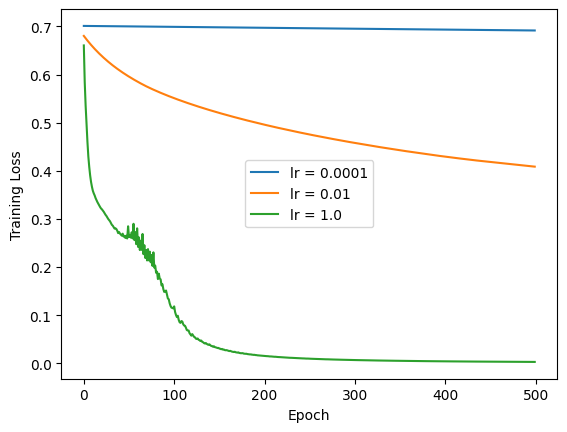

In [29]:
#A4 — Compare learning-rate experiments
import matplotlib.pyplot as plt
plt.plot(train_lossesA1, label = "lr = 0.0001")
plt.plot(train_lossesA2, label = "lr = 0.01")
plt.plot(train_lossesA3,label = "lr = 1.0")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

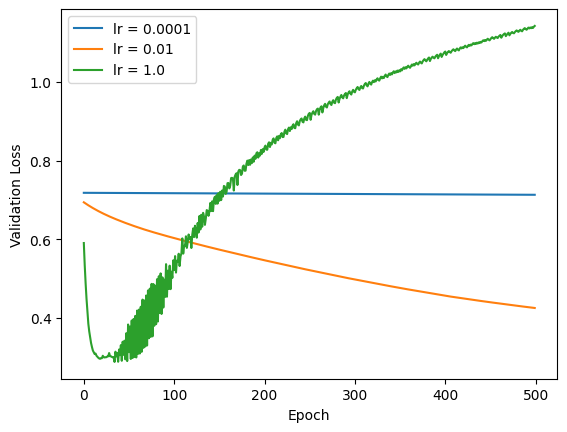

In [30]:
#A5 — Compare learning-rate experiments for Validation Loss
import matplotlib.pyplot as plt
plt.plot(val_lossesA1, label = "lr = 0.0001")
plt.plot(val_lossesA2, label = "lr = 0.01")
plt.plot(val_lossesA3,label = "lr = 1.0")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

#### Part B: Optmiser Experiments

In [6]:
modelB2 = MyModel()
optimiserB2 = torch.optim.Adam(modelB2.parameters(), lr = 0.01)

train_lossesB2 = []
val_lossesB2 = []

for epoch in range(500):
  modelB2.train()
  optimiserB2.zero_grad()
  train_logitsB2 = modelB2(x_train)
  train_lossB2 = loss_fn(train_logitsB2, y_train)
  train_lossB2.backward()
  optimiserB2.step()

  train_lossesB2.append(train_lossB2.item())

  modelB2.eval()
  with torch.no_grad():
    val_logitsB2 = modelB2(x_val)
    val_lossB2 = loss_fn(val_logitsB2, y_val)

  val_lossesB2.append(val_lossB2.item())



  if epoch%50 == 0:
    print(
        f"Epoch: {epoch}, Training Loss: {train_lossB2}"
        f"Epoch: {epoch}, VAlidation Loss: {val_lossB2}"
        )









Epoch: 0, Training Loss: 0.6202943921089172Epoch: 0, VAlidation Loss: 0.6093610525131226
Epoch: 50, Training Loss: 0.2506111264228821Epoch: 50, VAlidation Loss: 0.38956698775291443
Epoch: 100, Training Loss: 0.09324342757463455Epoch: 100, VAlidation Loss: 0.48251473903656006
Epoch: 150, Training Loss: 0.038201335817575455Epoch: 150, VAlidation Loss: 0.6388594508171082
Epoch: 200, Training Loss: 0.01954914629459381Epoch: 200, VAlidation Loss: 0.7579318284988403
Epoch: 250, Training Loss: 0.011807536706328392Epoch: 250, VAlidation Loss: 0.8548480272293091
Epoch: 300, Training Loss: 0.007898530922830105Epoch: 300, VAlidation Loss: 0.9288516640663147
Epoch: 350, Training Loss: 0.005674576852470636Epoch: 350, VAlidation Loss: 0.991950511932373
Epoch: 400, Training Loss: 0.004279278684407473Epoch: 400, VAlidation Loss: 1.0470781326293945
Epoch: 450, Training Loss: 0.003346838988363743Epoch: 450, VAlidation Loss: 1.0952982902526855


In [7]:
import matplotlib.pyplot as plt


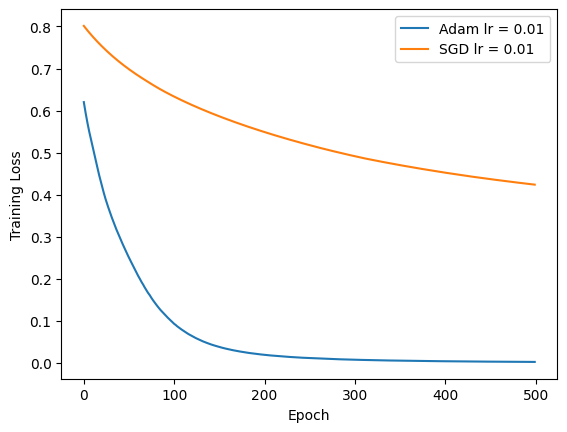

In [11]:
n

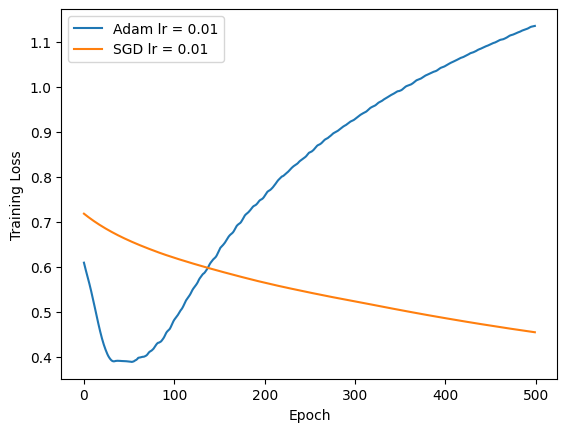

In [13]:
plt.plot(val_lossesB2, label = "Adam lr = 0.01")
plt.plot(val_lossesA2, label = "SGD lr = 0.01")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

SGD vs Adam experiment

1. same nominal lr = 0.01
2. Adam optimized the training set faster
3. SGD generalized better over this particular 500-epoch toy experiment